# Ex1 — SMLM: calibrate the pupil from a bead stack, then generate training data

Single-molecule localisation microscopy (SMLM) trains detection and localisation networks on
simulated frames, and they only transfer to real data when the simulated PSF matches the
microscope's. This example does both halves of that workflow:

1. **Calibrate.** Record a focus stack of one bead through an oil objective and a coverslip,
   then recover the objective's aberrations (Zernike coefficients), the bead's position and its
   brightness by maximising the camera likelihood.
2. **Generate.** Build one Pipeline with the calibrated pupil and feed it batch after batch of
   emitters sampled in plain torch: varying counts, sCMOS noise with per-pixel maps,
   reproducible image keys, and labels (emitter tables and heatmaps) in the image's frame.

**Level** L2 (the fit) and L3 (a Pipeline for generation) · **Prerequisites** T1 ·
**Runtime** a few seconds on a GPU. `SMOKE` (set by the test suite) shrinks every size, so
the notebook also runs in seconds on a CPU.

In [1]:
import os
import time

import matplotlib.pyplot as plt
import torch
from matplotlib.colors import PowerNorm
from matplotlib.image import AxesImage
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import gradix as gx
from gradix.special.zernike import zernike_ansi

SMOKE = os.environ.get("GRADIX_SMOKE") == "1"  # small shapes and few iterations for the tests
DEVICE = "cuda" if torch.cuda.is_available() and not SMOKE else "cpu"
DTYPE = torch.float64  # the fit uses double precision; generation below uses float32
_ = torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9})


def show(
    ax: plt.Axes, frame: torch.Tensor, title: str, extent: tuple, norm: PowerNorm
) -> AxesImage:
    """Draw a frame in µm without ticks, on a shared (square-root) colour scale."""
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax.imshow(frame.detach().cpu().numpy(), extent=extent, cmap="magma", norm=norm)


def scale_bar(ax: plt.Axes, length: float = 1.0) -> None:
    """Draw a scale bar of ``length`` µm."""
    bar = AnchoredSizeBar(
        ax.transData,
        length,
        f"{length:g} µm",
        "lower left",
        pad=0.4,
        color="white",
        frameon=False,
        size_vertical=0.03,
    )
    ax.add_artist(bar)

## 1. The microscope, and the aberrations we will pretend not to know

An NA 1.45 oil objective images a water sample through a coverslip
(`gx.env.WaterOnCoverslip`), onto an sCMOS camera whose gain, offset and read noise vary per
pixel. The calibration uses a crop of the sensor around the bead (`roi=`); generation later uses
the whole sensor. The objective carries five aberrations, as OSA/ANSI Zernike coefficients in µm
of optical path: the "unknowns" of the calibration.

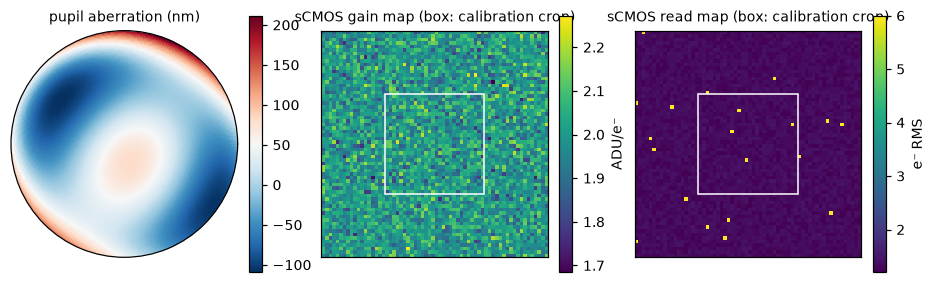

In [2]:
sensor, shape = ((32, 32), (20, 20)) if SMOKE else ((64, 64), (28, 28))
g = torch.Generator().manual_seed(1)
maps = {  # per-pixel calibration maps, as a camera vendor would supply them
    "gain": 2.0 * (1 + 0.04 * torch.randn(sensor, generator=g)),  # ADU per electron
    "offset": 100.0 + 2.0 * torch.randn(sensor, generator=g),  # ADU
    "read": 1.2 + 0.25 * torch.rand(sensor, generator=g),  # electrons, RMS
}
maps["read"].view(-1)[torch.randint(0, maps["read"].numel(), (20,), generator=g)] = (
    6.0  # hot pixels
)
corner = (sensor[0] - shape[0]) // 2
camera = gx.Camera.scmos(pixel_size=6.5, maps=maps, roi=(corner, corner, *shape))  # a crop
medium = gx.env.WaterOnCoverslip()

names = [
    "oblique astigmatism",
    "vertical astigmatism",
    "vertical coma",
    "horizontal coma",
    "primary spherical",
]
indices = (3, 5, 7, 8, 12)
truth = torch.tensor([0.035, -0.02, 0.025, -0.015, 0.03], dtype=DTYPE)  # µm of OPD

rho, phi = torch.meshgrid(
    torch.linspace(0, 1, 128), torch.linspace(-torch.pi, torch.pi, 256), indexing="ij"
)
opd = sum(c * zernike_ansi(j, rho, phi) for c, j in zip(truth.float(), indices, strict=True))
fig = plt.figure(figsize=(8.4, 3.0), layout="constrained")
ax = fig.add_subplot(1, 3, 1, projection="polar")
mesh = ax.pcolormesh(phi.numpy(), rho.numpy(), 1000 * opd.numpy(), cmap="RdBu_r", shading="auto")
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("pupil aberration (nm)")
fig.colorbar(mesh, ax=ax, shrink=0.8)
for i, (key, unit) in enumerate([("gain", "ADU/e⁻"), ("read", "e⁻ RMS")]):
    ax = fig.add_subplot(1, 3, i + 2)
    im = ax.imshow(maps[key].numpy(), cmap="viridis")
    ax.add_patch(
        plt.Rectangle(
            (corner - 0.5, corner - 0.5),
            shape[1],
            shape[0],
            fill=False,
            edgecolor="white",
            linewidth=1.0,
        )
    )
    ax.set_title(f"sCMOS {key} map (box: calibration crop)")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.8, label=unit)
plt.show()

## 2. Record a bead stack

One bead 0.8 µm below the coverslip is imaged while the focus steps through it
(`gx.acq.FocusStack`). The acquisition binds each frame's focus to `objective.focus`, so the
layered medium's focal shift and supercritical collection are modelled plane by plane.

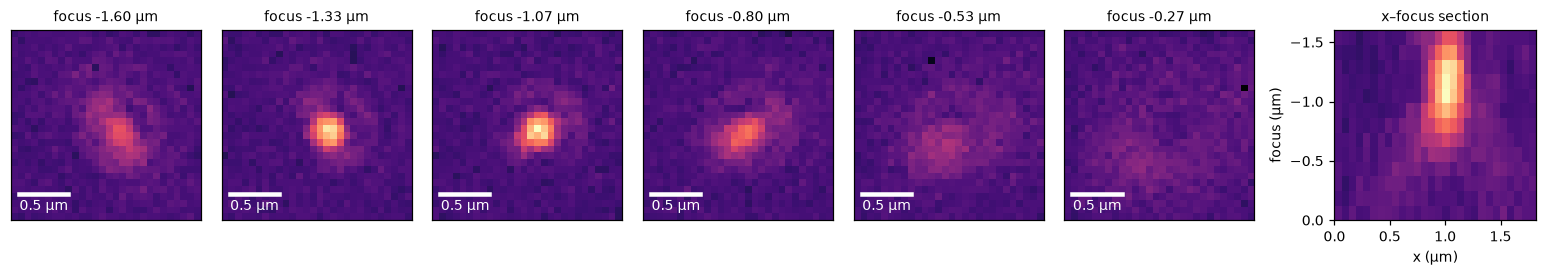

In [3]:
planes = 7 if SMOKE else 13
steps = torch.linspace(-1.6, 0.0, planes, dtype=DTYPE)  # nominal focus positions, µm
bead_true = torch.tensor([[[1.03, 0.95, -0.8]]], dtype=DTYPE)  # µm; z < 0 is in the sample
photons_true = torch.tensor([[8000.0]], dtype=DTYPE)
pitch = float(gx.coords.pitch(camera, gx.Objective(NA=1.45, magnification=100)))


def render_stack(
    coeffs: torch.Tensor, position: torch.Tensor, photons: torch.Tensor
) -> torch.Tensor:
    """Render the expected bead stack [1, planes, H, W] in ADU."""
    zernike = gx.pupil.Zernike(coeffs=coeffs, indices=indices)
    objective = gx.Objective(NA=1.45, magnification=100, pupil=(zernike,))
    bead = gx.Emitters(position=position, photons=photons, emission=gx.Spectrum.line(0.68))
    chain = gx.Chain(
        emitters={"bead": bead},
        imaging=gx.imaging.PointPSF(objective, camera, psf="scalar", roi=shape[0]),
        environment=medium,
        acquisition=gx.acq.FocusStack(focus=steps),
    )
    return chain(outputs=("expected",)).expected


measured = camera.sample(render_stack(truth, bead_true, photons_true), key=torch.tensor([3]))
extent = (0.0, shape[1] * pitch, shape[0] * pitch, 0.0)
norm = PowerNorm(0.5, vmin=float(measured.min()), vmax=float(measured.max()))
show_planes = list(range(0, planes, max(1, planes // 6)))[:6]
fig, axes = plt.subplots(
    1, len(show_planes) + 1, figsize=(2.0 * (len(show_planes) + 1), 2.4), layout="constrained"
)
for ax, k in zip(axes, show_planes, strict=False):
    show(ax, measured[0, k], f"focus {float(steps[k]):+.2f} µm", extent, norm)
    scale_bar(ax, 0.5)
row = round(float(bead_true[0, 0, 1]) / pitch - 0.5)
xz = measured[0, :, row, :]  # the stack through the bead's row: x against focus
axes[-1].imshow(
    xz.numpy(),
    cmap="magma",
    aspect="auto",
    norm=norm,
    extent=(0.0, shape[1] * pitch, float(steps[-1]), float(steps[0])),
)
axes[-1].set_title("x–focus section")
axes[-1].set_xlabel("x (µm)")
axes[-1].set_ylabel("focus (µm)")
plt.show()

## 3. Fit the pupil by maximum likelihood

The model is the same function that produced the data, now of learnable tensors: the five
Zernike coefficients, the bead's position and its (log) photon count. L-BFGS minimises the
negative log-likelihood of the sCMOS camera, which weighs every pixel by its own gain, offset
and read noise, hot pixels included.

In [4]:
coeffs = torch.zeros(len(indices), dtype=DTYPE, requires_grad=True)
position = (bead_true + torch.tensor([[[0.06, -0.05, 0.12]]], dtype=DTYPE)).requires_grad_()
log_photons = torch.tensor([[8.5]], dtype=DTYPE, requires_grad=True)  # a rough start: e^8.5 ≈ 4900
optimiser = torch.optim.LBFGS(
    [coeffs, position, log_photons], max_iter=15 if SMOKE else 100, line_search_fn="strong_wolfe"
)
losses = []


def closure() -> torch.Tensor:
    """Return the negative log-likelihood of the measured stack (L-BFGS calls this)."""
    optimiser.zero_grad()
    loss = -camera.log_prob(measured, render_stack(coeffs, position, log_photons.exp())).sum()
    loss.backward()
    losses.append(loss.item())
    return loss


start = time.perf_counter()
optimiser.step(closure)
print(f"{len(losses)} likelihood evaluations in {time.perf_counter() - start:.1f} s")
print(f"{'aberration':22s} {'true (nm)':>10s} {'fitted (nm)':>12s}")
for name, t, f in zip(names, truth.tolist(), coeffs.detach().tolist(), strict=True):
    print(f"{name:22s} {1000 * t:10.1f} {1000 * f:12.1f}")
error = (1000 * (position.detach() - bead_true)).squeeze().tolist()
print("position error (nm):", ", ".join(f"{e:+.1f}" for e in error))
print(f"photons: {log_photons.exp().item():.0f} (true {photons_true.item():.0f})")

24 likelihood evaluations in 0.2 s
aberration              true (nm)  fitted (nm)
oblique astigmatism          35.0         35.0
vertical astigmatism        -20.0        -20.2
vertical coma                25.0         24.9
horizontal coma             -15.0        -15.6
primary spherical            30.0         30.2
position error (nm): +0.4, -0.9, +0.4
photons: 8024 (true 8000)


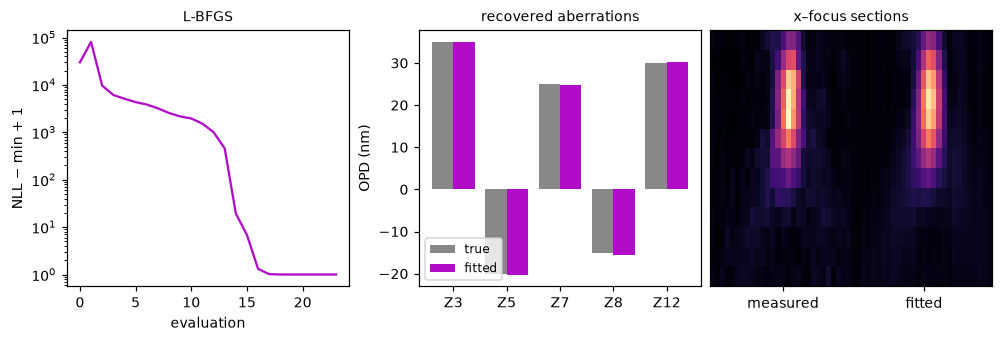

In [5]:
fitted = render_stack(coeffs.detach(), position.detach(), log_photons.exp().detach())
fig = plt.figure(figsize=(9.0, 3.0), layout="constrained")
ax = fig.add_subplot(1, 3, 1)
ax.semilogy([v - min(losses) + 1 for v in losses], color="#b10dc9")
ax.set_xlabel("evaluation")
ax.set_ylabel("NLL − min + 1")
ax.set_title("L-BFGS")
ax = fig.add_subplot(1, 3, 2)
x = torch.arange(len(indices)).numpy()
ax.bar(x - 0.2, 1000 * truth.numpy(), 0.4, label="true", color="#888888")
ax.bar(x + 0.2, 1000 * coeffs.detach().numpy(), 0.4, label="fitted", color="#b10dc9")
ax.set_xticks(x.tolist(), [f"Z{j}" for j in indices])
ax.set_ylabel("OPD (nm)")
ax.legend(fontsize=8, loc="lower left")
ax.set_title("recovered aberrations")
ax = fig.add_subplot(1, 3, 3)
both = torch.cat([measured[0, :, row, :], fitted[0, :, row, :]], dim=1)
ax.imshow(both.numpy(), cmap="magma", aspect="auto")
ax.set_xticks([shape[1] / 2, 1.5 * shape[1]], ["measured", "fitted"])
ax.set_yticks([])
ax.set_title("x–focus sections")
plt.show()

## 4. Generate training data with the calibrated pupil

Now the calibrated objective renders SMLM frames. The Pipeline is **built once**: its batch and
emitter slots are capacities, so every batch of new values is bound by field path
(`pipe({"beads.position": ...})`) without rebuilding anything. Emitter counts vary per image
through `presence`, and image keys make every frame's noise a function of its dataset index
alone, whatever batch it lands in. The whole sensor is used now, with the objective focused
0.6 µm into the sample and a uniform background of 5 photons per pixel.

In [6]:
B, N = (4, 8) if SMOKE else (64, 16)
calibrated = gx.pupil.Zernike(coeffs=coeffs.detach().float(), indices=indices)
objective = gx.Objective(NA=1.45, magnification=100, pupil=(calibrated,), focus=-0.6)
camera = gx.Camera.scmos(pixel_size=6.5, maps=maps)  # the whole sensor
fov = gx.coords.field_of_view(camera, objective)


def sample_batch(generator: torch.Generator) -> dict:
    """Plain-torch sampling: positions anywhere in the frame, 0.2–1 µm deep, varying counts."""
    xy = torch.rand(B, N, 2, generator=generator) * fov
    z = -0.2 - 0.8 * torch.rand(B, N, 1, generator=generator)
    photons = torch.exp(7.8 + 0.4 * torch.randn(B, N, generator=generator))  # log-normal, ~2400
    count = torch.randint(N // 4, N + 1, (B, 1), generator=generator)
    presence = (torch.arange(N)[None, :] < count).float()
    return {
        "beads.position": torch.cat([xy, z], -1),
        "beads.photons": photons,
        "beads.presence": presence,
    }


g = torch.Generator().manual_seed(7)
first = sample_batch(g)
beads = gx.Emitters(
    position=first["beads.position"],
    photons=first["beads.photons"],
    presence=first["beads.presence"],
    emission=gx.Spectrum.line(0.68),
)
# deep emitters at NA 1.45 spread wider than this small frame, so the global method (the whole
# frame per emitter, exact) is cheaper here than per-emitter ROIs; explain() says so otherwise
psf = gx.imaging.PointPSF(objective, camera, psf="scalar", method="global")
chain = gx.Chain(emitters={"beads": beads}, imaging=psf, environment=medium, background=5.0)
pipe = gx.Pipeline(
    gx.tree.to(chain, DEVICE),
    outputs={
        "image": "image",
        "table": gx.labels.EmitterTable("beads"),
        "heat": gx.labels.Heatmap("beads"),
    },
    envelope={"beads.position.z": (-1.1, -0.1)},  # the depths the sampler covers
)
print(pipe.explain().split("validity")[0])

Pipeline bc8748ba6c25 · B≤64 · cuda:0 · float32/complex64/fp64-special/ieee · built in 48 ms
slots      beads ≤ 16
envelope   beads.emission.wavelengths ∈ [0.68, 0.68] (derived)
           beads.position.x ∈ [-0.75, 5.25] (derived)
           beads.position.y ∈ [-0.75, 5.25] (derived)
           beads.position.z ∈ [-1.1, -0.1] (explicit)
           camera.pixel_size ∈ [6.5, 6.5] (derived)
           environment.coverslip.n ∈ [1.518, 1.518] (derived)
           environment.immersion.n ∈ [1.518, 1.518] (derived)
           environment.sample.n ∈ [1.333, 1.333] (derived)
           objective.NA ∈ [1.45, 1.45] (derived)
           objective.focus ∈ [-0.6, -0.6] (derived)
           objective.magnification ∈ [100, 100] (derived)
sampling   imaging: detection.spacing = 0.065  ← pitch/s, s the smallest integer with spacing <= λ_min/(2·2.9) = 0.1172 µm (auto)
           imaging: roi = 160  ← R·p ≥ 2(|Δz|·tanθ_max + 2λ_max/NA) + 4p, even and 2·3·5·7-smooth
           imaging: pupil.samples = 12

In [7]:
batches = 2 if SMOKE else 16
pipe({k: v.to(DEVICE) for k, v in first.items()}, key=torch.arange(B, device=DEVICE))  # warm-up
start = time.perf_counter()
for i in range(batches):
    values = {k: v.to(DEVICE) for k, v in sample_batch(g).items()}
    keys = torch.arange(i * B, (i + 1) * B, device=DEVICE)  # dataset indices → noise keys
    out = pipe(values, key=keys)
if DEVICE == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start
print(f"{batches * B} frames in {elapsed:.2f} s ({batches * B / elapsed:.0f} frames/s on {DEVICE})")
print(out)
# image keys: frame 3 of this batch, rendered alone, draws exactly the same noise
alone = pipe({k: v[3:4] for k, v in values.items()}, key=keys[3:4])
print(
    "frame rendered alone equals its slice of the batch:", torch.equal(alone.image, out.image[3:4])
)

1024 frames in 0.29 s (3568 frames/s on cuda)
Output(image: [64, 1, 64, 64], table: [64, 16, 5], table.in_fov: [64, 16], heat: [64, 64, 64])
frame rendered alone equals its slice of the batch: True


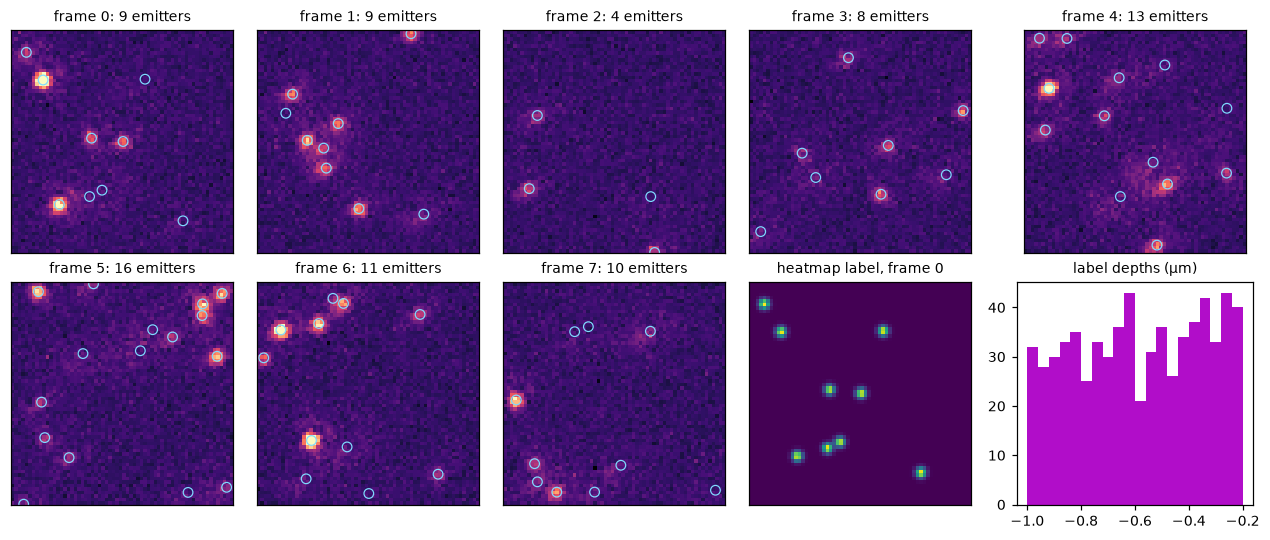

In [8]:
shown = 4 if SMOKE else 8
table = out.table.cpu()  # [B, N, 5]: x_px, y_px, z_µm, photons, presence
fig, axes = plt.subplots(
    2, shown // 2 + 1, figsize=(2.3 * (shown // 2 + 1), 4.8), layout="constrained"
)
low, high = float(out.image[:shown].min()), float(out.image[:shown].quantile(0.999))
for ax, b in zip(axes.flat, range(shown), strict=False):
    ax.imshow(out.image[b, 0].cpu().numpy(), cmap="magma", vmin=low, vmax=high)
    on = (table[b, :, 4] > 0) & out["table.in_fov"][b].cpu()
    ax.scatter(
        table[b, on, 0].numpy(),
        table[b, on, 1].numpy(),
        s=40,
        facecolors="none",
        edgecolors="#7fdbff",
        linewidths=0.8,
    )
    ax.set_title(f"frame {b}: {int(on.sum())} emitters")
    ax.set_xticks([])
    ax.set_yticks([])
axes.flat[-2].imshow(out.heat[0].cpu().numpy(), cmap="viridis")
axes.flat[-2].set_title("heatmap label, frame 0")
axes.flat[-1].hist(table[..., 2][table[..., 4] > 0].numpy(), bins=20, color="#b10dc9")
axes.flat[-1].set_title("label depths (µm)")
for ax in axes.flat[-2:-1]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## Recap

- One forward model served both halves: fitting (gradients to Zernikes, position and photons
  through the layered-medium PSF and the sCMOS likelihood) and generation.
- The generator is a Pipeline built once and fed plain-torch samples by field path; its
  `explain()` lists the envelope and sampling it planned for.
- Image keys tie each frame's noise to its dataset index, so datasets are reproducible item by
  item across batch sizes and orders.